In [1]:
import sys
import os 
import pandas as pd
#concectamos con la carpeta src
sys.path.append(os.path.abspath('../src'))
from data_processing import load_and_process_all

#ejecuta todo el flujo de una vez
df_completo = load_and_process_all(r'C:\Users\joseb\Desktop\proyecto _cm_ml\data\raw_data')

#verificar resultados
print(df_completo.groupby('Archivo_Origen')['Total'].sum()) #ver ventas por familias
df_completo

📂 Procesando 2 archivos...
   Processing: productos_clientes_MC_raw.csv...
   Processing: productos_clientes_SI_raw.csv...
✅ ¡ÉXITO! 71780 filas limpias.
Archivo_Origen
productos_clientes_MC_raw.csv    3244308.50
productos_clientes_SI_raw.csv     743776.98
Name: Total, dtype: float64


,Fecha,Cliente,Segmento,Grupo,Producto,Cantidad,Total,Archivo_Origen,Año,Mes
0,2022-04-08,OCASIONAL (ASUNCION),B2C_Ocasional,ADITIVOS,156,12110.0,1.00,productos_clientes_MC_raw.csv,2022,4
1,2022-05-11,OCASIONAL (ASUNCION),B2C_Ocasional,ADITIVOS,156,12110.0,1.00,productos_clientes_MC_raw.csv,2022,5
2,2022-07-07,OCASIONAL (ASUNCION),B2C_Ocasional,ADITIVOS,156,12110.0,1.00,productos_clientes_MC_raw.csv,2022,7
3,2022-09-17,OCASIONAL (ASUNCION),B2C_Ocasional,ADITIVOS,1775,19580.0,1.00,productos_clientes_MC_raw.csv,2022,9
4,2023-10-27,OCASIONAL (ASUNCION),B2C_Ocasional,ADITIVOS,1775,21570.0,1.00,productos_clientes_MC_raw.csv,2023,10
...,...,...,...,...,...,...,...,...,...,...
71775,2025-05-02,"CABRERA GALEANO, MIRTA (ASUNCIOM)",B2C_Particular,CERAMICA ESMALTADA,6343,160170.0,5.62,productos_clientes_SI_raw.csv,2025,5
71776,2025-04-23,"CABRERA GALEANO, MIRTA (ASUNCIOM)",B2C_Particular,DERIVADOS DEL CEMENTO IMPORTADOS,5549,184520.0,7.00,productos_clientes_SI_raw.csv,2025,4
71777,2025-05-02,"CABRERA GALEANO, MIRTA (ASUNCIOM)",B2C_Particular,DERIVADOS DEL CEMENTO IMPORTADOS,5549,52720.0,2.00,productos_clientes_SI_raw.csv,2025,5
71778,2025-05-12,"CABRERA GALEANO, MIRTA (ASUNCIOM)",B2C_Particular,DERIVADOS DEL CEMENTO IMPORTADOS,5549,184520.0,7.00,productos_clientes_SI_raw.csv,2025,5


🔎 Dimensiones: (71780, 10)

📋 Columnas: ['Fecha', 'Cliente', 'Segmento', 'Grupo', 'Producto', 'Cantidad', 'Total', 'Archivo_Origen', 'Año', 'Mes']

Primeras filas:
        Fecha               Cliente       Segmento     Grupo Producto  \
0 2022-04-08  OCASIONAL (ASUNCION)  B2C_Ocasional  ADITIVOS      156   
1 2022-05-11  OCASIONAL (ASUNCION)  B2C_Ocasional  ADITIVOS      156   
2 2022-07-07  OCASIONAL (ASUNCION)  B2C_Ocasional  ADITIVOS      156   
3 2022-09-17  OCASIONAL (ASUNCION)  B2C_Ocasional  ADITIVOS     1775   
4 2023-10-27  OCASIONAL (ASUNCION)  B2C_Ocasional  ADITIVOS     1775   

   Cantidad  Total                 Archivo_Origen   Año  Mes  
0   12110.0    1.0  productos_clientes_MC_raw.csv  2022    4  
1   12110.0    1.0  productos_clientes_MC_raw.csv  2022    5  
2   12110.0    1.0  productos_clientes_MC_raw.csv  2022    7  
3   19580.0    1.0  productos_clientes_MC_raw.csv  2022    9  
4   21570.0    1.0  productos_clientes_MC_raw.csv  2023   10  

ℹ️ Información del data

c:\Users\joseb\Desktop\proyecto _cm_ml\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


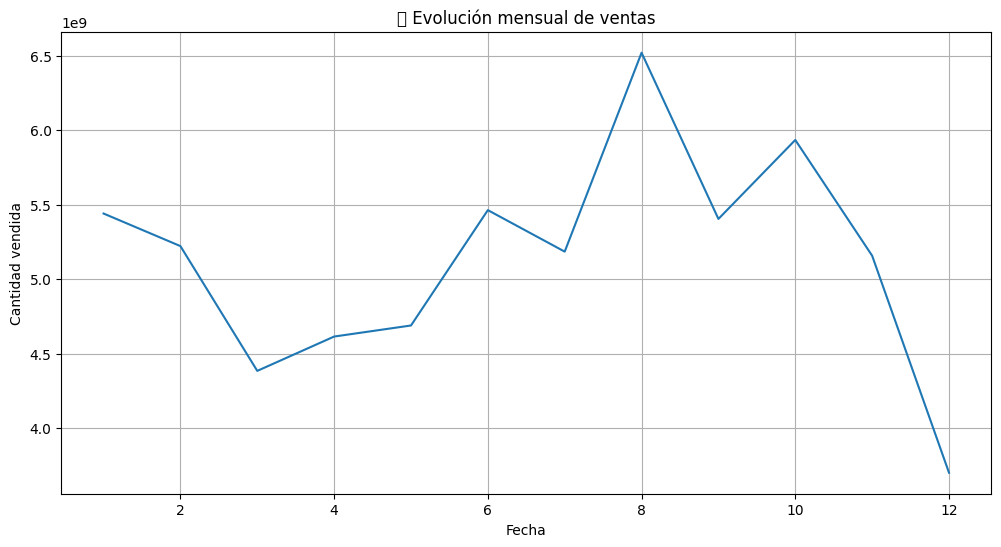

C:\Users\joseb\AppData\Local\Temp\ipykernel_31616\2995905107.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_prod.index, y=top_prod.values, palette="viridis")
c:\Users\joseb\Desktop\proyecto _cm_ml\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


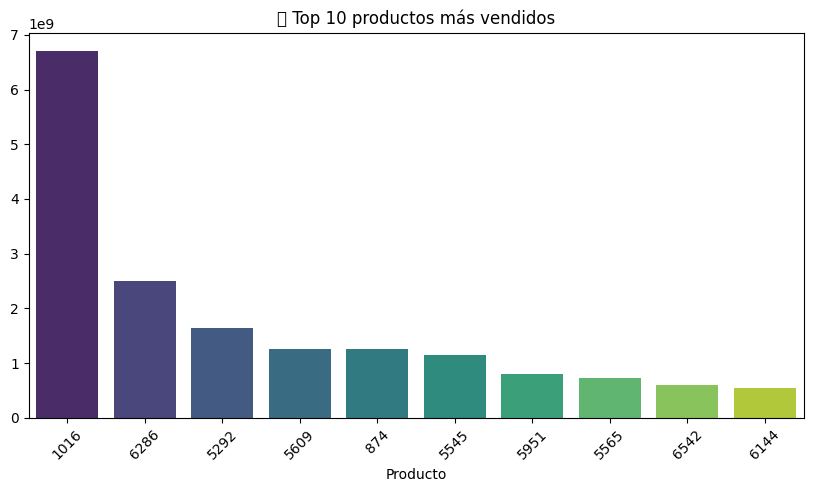

AttributeError: Can only use .dt accessor with datetimelike values

In [2]:
# ------------------------------------------------------------------
# EDA DE NEGOCIOS SOBRE DATOS DE VENTAS
# ------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = df_completo

# 2. Vista general
print("🔎 Dimensiones:", df.shape)
print("\n📋 Columnas:", df.columns.tolist())
print("\nPrimeras filas:\n", df.head())

# 3. Info y valores nulos
print("\nℹ️ Información del dataset:")
print(df.info())
print("\n❌ Valores nulos por columna:\n", df.isnull().sum())

# 4. Estadísticas descriptivas
print("\n📊 Estadísticas descriptivas:")
print(df.describe(include='all'))

# ------------------------------------------------------------------
# ANÁLISIS DE NEGOCIO
# ------------------------------------------------------------------

# 5. Evolución temporal de ventas
plt.figure(figsize=(12,6))
df.groupby('Mes')['Cantidad'].sum().plot()
plt.title("📈 Evolución mensual de ventas")
plt.ylabel("Cantidad vendida")
plt.xlabel("Fecha")
plt.grid(True)
plt.show()

# 6. Ventas por producto / categoría
if 'Producto' in df.columns:
    top_prod = df.groupby('Producto')['Cantidad'].sum().sort_values(ascending=False).head(10)
    plt.figure(figsize=(10,5))
    sns.barplot(x=top_prod.index, y=top_prod.values, palette="viridis")
    plt.title("🏆 Top 10 productos más vendidos")
    plt.xticks(rotation=45)
    plt.show()

if 'Categoria' in df.columns:
    cat_sales = df.groupby('Categoria')['Cantidad'].sum().sort_values(ascending=False)
    plt.figure(figsize=(8,5))
    sns.barplot(x=cat_sales.index, y=cat_sales.values, palette="magma")
    plt.title("📦 Ventas por categoría")
    plt.xticks(rotation=45)
    plt.show()

# 7. Estacionalidad: ventas por mes
df['Mes'] = df['Mes'].dt.month
mes_sales = df.groupby('Mes')['Cantidad'].sum()
plt.figure(figsize=(8,5))
sns.lineplot(x=mes_sales.index, y=mes_sales.values, marker="o")
plt.title("📅 Estacionalidad: ventas por mes")
plt.xlabel("Mes")
plt.ylabel("Cantidad vendida")
plt.grid(True)
plt.show()

# 8. Ventas por año
df['Año'] = df['Ano'].dt.year
year_sales = df.groupby('Año')['Cantidad'].sum()
plt.figure(figsize=(8,5))
sns.barplot(x=year_sales.index, y=year_sales.values, palette="coolwarm")
plt.title("📊 Ventas por año")
plt.ylabel("Cantidad vendida")
plt.show()

# 9. Correlaciones entre variables numéricas
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="Blues")
plt.title("🔗 Correlaciones entre variables")
plt.show()

# 10. KPI básicos
total_ventas = df['Cantidad'].sum()
ventas_promedio_mes = df.groupby('Fecha_Mensual')['Cantidad'].sum().mean()
print("\n💡 KPI de negocio:")
print(f"➡️ Total de ventas: {total_ventas:,.0f}")
print(f"➡️ Promedio mensual de ventas: {ventas_promedio_mes:,.0f}")
if 'Producto' in df.columns:
    print(f"➡️ Producto más vendido: {df.groupby('Producto')['Cantidad'].sum().idxmax()}")
if 'Categoria' in df.columns:
    print(f"➡️ Categoría más vendida: {df.groupby('Categoria')['Cantidad'].sum().idxmax()}")